In [32]:
import numpy as np
import tqdm as tqdm
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.colors import Normalize
from numba import njit, prange

In [33]:
MU_0 = 4e-7 * np.pi # магнитная постоянная
EPS_0 = 8.8541878188e-12 # электрическая постоянная
ETA_0 = np.sqrt(MU_0/EPS_0) # волновое сопротивление свободного пространства
C = 1/np.sqrt(MU_0*EPS_0) # скорость света в вакууме

In [34]:
nlamb = 30 # количество точек на одну длину волны
f = 100e6 # частота
lamb = C/f # длина волны
t = 1/f # период
dx = lamb/nlamb # шаг вдоль оси x
dy = lamb/nlamb # шаг вдоль оси y
dz = lamb/nlamb # шаг вдоль оси z
dt = dx/C/np.sqrt(3)/4 # шаг по времени
N_lamb = 5 # количество длин волн в расчетной области
N_t = 10 # количество периодов для моделирования
nx = int(N_lamb*nlamb) # количество точек вдоль оси x
ny = int(N_lamb*nlamb) # количество точек вдоль оси y
nz = int(N_lamb*nlamb) # количество точек вдоль оси z
nt = int(N_t*t/dt) # количество временных шагов
print(f"Шаг по времени: {dt:.2e} с, количество временных шагов: {nt}")
print(f"Размер расчетной области: {nx*dx:.2f} м x {ny*dy:.2f} м x {nz*dz:.2f} м, количество точек: {nx} x {ny} x {nz}")

Шаг по времени: 4.81e-11 с, количество временных шагов: 2078
Размер расчетной области: 14.99 м x 14.99 м x 14.99 м, количество точек: 150 x 150 x 150


In [35]:
# Крайние слои массивов заполнены нулями для реализации сдвига по индексам
Ex = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Ey = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Ez = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Hx = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Hy = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
Hz = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
sigmx = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
sigmy = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
sigmz = np.zeros((nx+2, ny+2, nz+2), dtype=np.float32)
mu = np.ones((nx+2, ny+2, nz+2), dtype=np.float32)*MU_0
eps = np.ones((nx+2, ny+2, nz+2), dtype=np.float32)*EPS_0

In [36]:
#добавление диполя
l = lamb*0.5
l_section = l/2
n_section = int(l_section/dx)
x_c = nx//2 + 1
y_c = ny//2 + 1
z_c = nz//2 + 1
dipole_zindexes = np.r_[z_c-n_section+1:z_c, z_c:z_c+n_section]
sigmz[x_c, y_c, z_c+1:z_c+n_section] = 1e+25
sigmz[x_c, y_c, z_c-n_section+1:z_c] = 1e+25

In [37]:
# z-компонента тока в ячейке (i, j, k) 


def Jz_check(i, j, k):
    return sigmz[i, j, k] * Ez[i, j, k]
def Jz(i, j, k):
    return (Hy[i, j, k] - Hy[i-1, j, k])*dy - (Hx[i, j, k] - Hx[i, j-1, k])*dx

def CA_maker(sample_t_dep): #преобразование временной зависимости в комплексную амплитуду
    start = int(5*t/dt)
    end = start + int(2*t/dt)
    lenth = end - start
    CA = np.zeros(lenth, dtype=np.float32)
    time = np.arange(start, end)*dt
    basic = np.exp(-1j*2*np.pi*f*time)
    ca = np.sum(sample_t_dep[start:end]*basic)/lenth
    return ca

In [38]:
J_dipole = np.zeros((nt, len(dipole_zindexes)), dtype=np.float32)

In [39]:
Ez_time = np.zeros((nt, nx, ny), dtype=np.float32) # массив для сохранения Ez в центре расчетной области в каждый момент времени

In [40]:
c_1x = (1 - sigmx*dt/(2*eps)) / (1 + sigmx*dt/(2*eps))
c_1y = (1 - sigmy*dt/(2*eps)) / (1 + sigmy*dt/(2*eps))
c_1z = (1 - sigmz*dt/(2*eps)) / (1 + sigmz*dt/(2*eps))
c_2x = 1/(1 + sigmx*dt/(2*eps))
c_2y = 1/(1 + sigmy*dt/(2*eps))
c_2z = 1/(1 + sigmz*dt/(2*eps))

In [41]:
@njit(parallel=True, fastmath=True)
def Next_step_Hfield(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps, dx=dx, dy=dy, dz=dz, dt=dt, c_1x=c_1x, c_2x=c_2x, c_1y=c_1y, c_2y=c_2y, c_1z=c_1z, c_2z=c_2z):
    # обновление магнитного поля
    for i in prange(1, nx+1):
        for j in range(1, ny+1):
            for k in range(1, nz+1):
                Hx[i, j, k] = Hx[i, j, k] + dt/mu[i, j, k] * ((Ey[i, j, k] - Ey[i, j, k-1])/dz - (Ez[i, j+1, k] - Ez[i, j, k])/dy)
                Hy[i, j, k] = Hy[i, j, k] + dt/mu[i, j, k] * ((Ez[i+1, j, k] - Ez[i, j, k])/dx - (Ex[i, j, k] - Ex[i, j, k-1])/dz)
                Hz[i, j, k] = Hz[i, j, k] + dt/mu[i, j, k] * ((Ex[i, j+1, k] - Ex[i, j, k])/dy - (Ey[i+1, j, k] - Ey[i, j, k])/dx)
    return
@njit(parallel=True, fastmath=True)
def Next_step_Efield(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps, dx=dx, dy=dy, dz=dz, dt=dt, c_1x=c_1x, c_2x=c_2x, c_1y=c_1y, c_2y=c_2y, c_1z=c_1z, c_2z=c_2z):
    # обновление электрического поля
    for i in prange(1, nx+1):
        for j in range(1, ny+1):
            for k in range(1, nz+1):
                    Ex[i, j, k] = c_1x[i, j, k]*Ex[i, j, k] - dt/eps[i, j, k]*c_2x[i, j, k] * ((Hy[i, j, k+1] - Hy[i, j, k])/dz - (Hz[i, j, k] - Hz[i, j-1, k])/dy)
                    Ey[i, j, k] = c_1y[i, j, k]*Ey[i, j, k] - dt/eps[i, j, k]*c_2y[i, j, k] * ((Hz[i, j, k] - Hz[i-1, j, k])/dx - (Hx[i, j, k+1] - Hx[i, j, k])/dz)
                    Ez[i, j, k] = c_1z[i, j, k]*Ez[i, j, k] - dt/eps[i, j, k]*c_2z[i, j, k] * ((Hx[i, j, k] - Hx[i, j-1, k])/dy - (Hy[i, j, k] - Hy[i-1, j, k])/dx)
    return

@njit(parallel=True, fastmath=True)
def PGU_x_max(Ey, Ez, E_y_old, E_z_old, dx=dx, dt=dt):
     for j in prange(1, ny+1):
        for k in range(1, nz+1):
            Ey[nx+1, j, k] = E_y_old[1, j, k] - (dx - C*dt)/(dx + C*dt) * (Ey[nx, j, k] - E_y_old[0, j, k])
            Ez[nx+1, j, k] = E_z_old[1, j, k] - (dx - C*dt)/(dx + C*dt) * (Ez[nx, j, k] - E_z_old[0, j, k])

@njit(parallel=True, fastmath=True)
def PGU_x_min(Hy, Hz, H_y_old, H_z_old, dx=dx, dt=dt):
     for j in prange(1, ny+1):
        for k in range(1, nz+1):
            Hy[0, j, k] = H_y_old[1, j, k] - (dx - C*dt)/(dx + C*dt) * (Hy[1, j, k] - H_y_old[0, j, k])
            Hz[0, j, k] = H_z_old[1, j, k] - (dx - C*dt)/(dx + C*dt) * (Hz[1, j, k] - H_z_old[0, j, k])

@njit(parallel=True, fastmath=True)
def PGU_y_max(Ex, Ez, E_x_old, E_z_old, dy=dy, dt=dt):
     for i in prange(1, nx+1):
        for k in range(1, nz+1):
            Ex[i, ny+1, k] = E_x_old[1, i, k] - (dy - C*dt)/(dy + C*dt) * (Ex[i, ny, k] - E_x_old[0, i, k])
            Ez[i, ny+1, k] = E_z_old[1, i, k] - (dy - C*dt)/(dy + C*dt) * (Ez[i, ny, k] - E_z_old[0, i, k])

@njit(parallel=True, fastmath=True)
def PGU_y_min(Hx, Hz, H_x_old, H_z_old, dy=dy, dt=dt):
    for i in prange(1, nx+1):
        for k in range(1, nz+1):
            Hx[i, 0, k] = H_x_old[1, i, k] - (dy - C*dt)/(dy + C*dt) * (Hx[i, 1, k] - H_x_old[0, i, k])
            Hz[i, 0, k] = H_z_old[1, i, k] - (dy - C*dt)/(dy + C*dt) * (Hz[i, 1, k] - H_z_old[0, i, k])

@njit(parallel=True, fastmath=True)
def PGU_z_max(Hx, Hy, H_x_old, H_y_old, dz=dz, dt=dt):
     for i in prange(1, nx+1):
        for j in range(1, ny+1):
            Hx[i, j, nz+1] = H_x_old[1, i, j] - (dz - C*dt)/(dz + C*dt) * (Hx[i, j, nz] - H_x_old[0, i, j])
            Hy[i, j, nz+1] = H_y_old[1, i, j] - (dz - C*dt)/(dz + C*dt) * (Hy[i, j, nz] - H_y_old[0, i, j])

@njit(parallel=True, fastmath=True)
def PGU_z_min(Ex, Ey, E_x_old, E_y_old, dz=dz, dt=dt):
     for i in prange(1, nx+1):
        for j in range(1, ny+1):
            Ex[i, j, 0] = E_x_old[1, i, j] - (dz - C*dt)/(dz + C*dt) * (Ex[i, j, 1] - E_x_old[0, i, j])
            Ey[i, j, 0] = E_y_old[1, i, j] - (dz - C*dt)/(dz + C*dt) * (Ey[i, j, 1] - E_y_old[0, i, j])

In [42]:
Ey_old_xmax = np.zeros((2, ny+2, nz+2), dtype=np.float32)
Ez_old_xmax = np.zeros((2, ny+2, nz+2), dtype=np.float32)
Hy_old_xmin = np.zeros((2, ny+2, nz+2), dtype=np.float32)
Hz_old_xmin = np.zeros((2, ny+2, nz+2), dtype=np.float32)
Ex_old_ymax = np.zeros((2, nx+2, nz+2), dtype=np.float32)
Ez_old_ymax = np.zeros((2, nx+2, nz+2), dtype=np.float32)
Hx_old_ymin = np.zeros((2, nx+2, nz+2), dtype=np.float32)
Hz_old_ymin = np.zeros((2, nx+2, nz+2), dtype=np.float32)
Hx_old_zmax = np.zeros((2, nx+2, ny+2), dtype=np.float32)
Hy_old_zmax = np.zeros((2, nx+2, ny+2), dtype=np.float32)
Ex_old_zmin = np.zeros((2, nx+2, ny+2), dtype=np.float32)
Ey_old_zmin = np.zeros((2, nx+2, ny+2), dtype=np.float32)
for i_t in tqdm.tqdm(range(nt)):
    Ey_old_xmax[0] = Ey[-1, :, :].copy()
    Ey_old_xmax[1] = Ey[-2, :, :].copy()
    Ez_old_xmax[0] = Ez[-1, :, :].copy()
    Ez_old_xmax[1] = Ez[-2, :, :].copy()
    Hy_old_xmin[0] = Hy[0, :, :].copy()
    Hy_old_xmin[1] = Hy[1, :, :].copy()
    Hz_old_xmin[0] = Hz[0, :, :].copy()
    Hz_old_xmin[1] = Hz[1, :, :].copy()
    Ex_old_ymax[0] = Ex[:, -1, :].copy()
    Ex_old_ymax[1] = Ex[:, -2, :].copy()
    Ez_old_ymax[0] = Ez[:, -1, :].copy()
    Ez_old_ymax[1] = Ez[:, -2, :].copy()
    Hx_old_ymin[0] = Hx[:, 0, :].copy()
    Hx_old_ymin[1] = Hx[:, 1, :].copy()
    Hz_old_ymin[0] = Hz[:, 0, :].copy()
    Hz_old_ymin[1] = Hz[:, 1, :].copy()
    Hx_old_zmax[0] = Hx[:, :, -1].copy()
    Hx_old_zmax[1] = Hx[:, :, -2].copy()
    Hy_old_zmax[0] = Hy[:, :, -1].copy()
    Hy_old_zmax[1] = Hy[:, :, -2].copy()
    Ex_old_zmin[0] = Ex[:, :, 0].copy()
    Ex_old_zmin[1] = Ex[:, :, 1].copy()
    Ey_old_zmin[0] = Ey[:, :, 0].copy()
    Ey_old_zmin[1] = Ey[:, :, 1].copy()
    Next_step_Efield(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps)
    PGU_x_max(Ey, Ez, Ey_old_xmax, Ez_old_xmax)
    PGU_y_max(Ex, Ez, Ex_old_ymax, Ez_old_ymax)
    PGU_z_min(Ex, Ey, Ex_old_zmin, Ey_old_zmin)
    Ez[x_c, y_c, z_c] = 1.0 * np.sin(2*np.pi*f*dt*i_t) # источник в центре расчетной области
    Next_step_Hfield(Ex, Ey, Ez, Hx, Hy, Hz, mu, eps)
    PGU_x_min(Hy, Hz, Hy_old_xmin, Hz_old_xmin)
    PGU_y_min(Hx, Hz, Hx_old_ymin, Hz_old_ymin)
    PGU_z_max(Hx, Hy, Hx_old_zmax, Hy_old_zmax)
    Ez_time[i_t] =  (Ez[1:-1, y_c, 1:-1])
    k_temp = 0
    for k in dipole_zindexes:
        J_dipole[i_t, k_temp] = Jz(x_c, y_c, k)
        k_temp += 1

100%|██████████| 2078/2078 [01:07<00:00, 30.62it/s]


[ 47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64
  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82
  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100
 101 102 103 104 105]


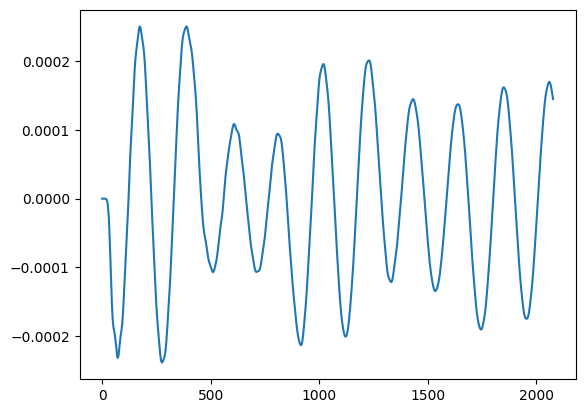

In [282]:
print(dipole_zindexes)
plt.plot(J_dipole[:, 25])

[ 47  48  49  50  51  52  53  54  55  56  57  58  59  60  61  62  63  64
  65  66  67  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82
  83  84  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 100
 101 102 103 104 105]


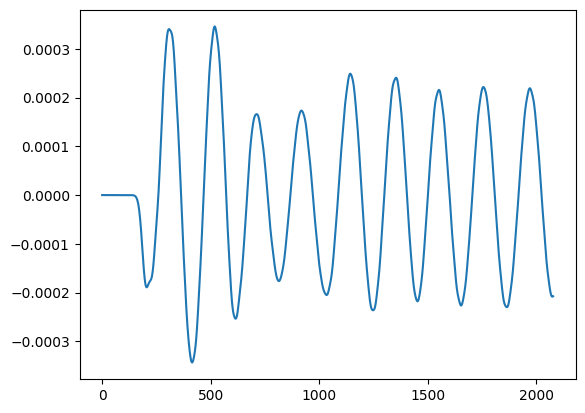

In [283]:
print(dipole_zindexes)
plt.plot(J_dipole[:, 5])

424.711113315155


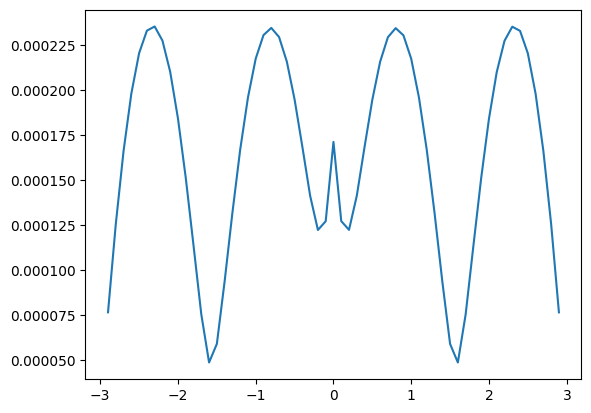

In [284]:
ca_dipole_current = []
for i in range(len(dipole_zindexes)):
    ca_dipole_current.append(CA_maker(J_dipole[:, i]))
z_coordinates = dipole_zindexes*dz - z_c*dz
plt.plot(z_coordinates, np.abs(ca_dipole_current[:])*2)
#plt.plot(np.angle(np.array(ca_dipole_current)*1.j))
print(dz/np.abs(ca_dipole_current[6])/2)

In [285]:
print(CA_maker(J_dipole[:, 6]))

(-0.00011755776272799849-4.5462551983279825e-06j)


In [286]:
def dipole_far_field_from_current(I_z, z_coords, lamb, theta):
    k = 2 * np.pi / lamb
    dz = np.mean(np.diff(z_coords)) if len(z_coords) > 1 else 1.0

    F = np.zeros_like(theta, dtype=np.complex128)
    for i, th in enumerate(theta):
        phase = np.exp(1j * k * z_coords * np.cos(th))
        F[i] = np.sum(I_z * phase) * dz

    E_theta = np.sin(theta) * F
    return E_theta

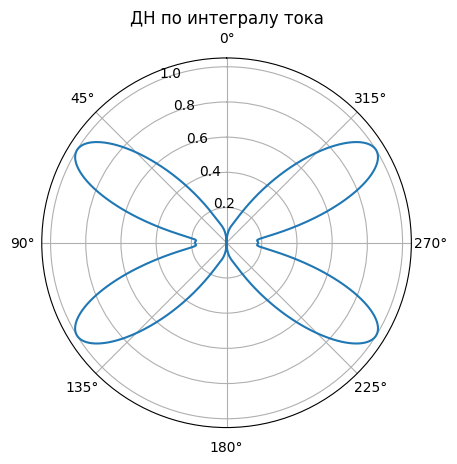

In [287]:

theta = np.linspace(0, 2*np.pi, 1001)
E_theta = dipole_far_field_from_current(ca_dipole_current, z_coordinates, lamb, theta)
pattern = np.abs(E_theta)
pattern /= pattern.max()

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
ax.set_theta_zero_location(loc='N')
ax.plot(theta, pattern)
ax.set_title("ДН по интегралу тока")
plt.show()

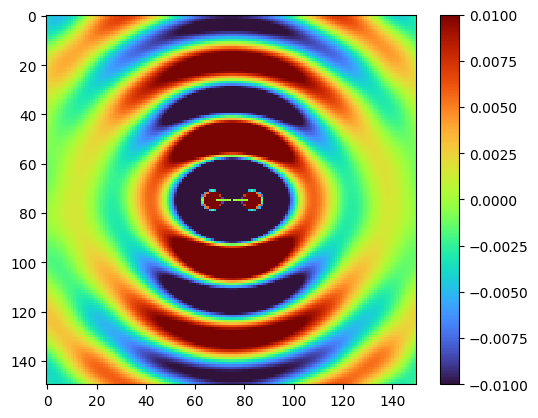

In [49]:
da = 24  # сохраняем каждый n-ый кадр
data = Ez_time[::da]  # сечение Ez
fig, ax = plt.subplots()
norm = Normalize(vmin=-1e-2, vmax=1e-2)
im = ax.imshow(data[0], cmap='turbo', norm=norm, interpolation="nearest", animated=True)
fig.colorbar(im, ax=ax)

def update(frame):
    im.set_array(data[frame])
    return [im]

ani = animation.FuncAnimation(fig, update, frames=len(data), blit=True)

# Сохраняем анимацию в GIF
ani.save("вырвиглазный_heatmap_0_5_lamb.gif", writer='pillow', fps=15, dpi=100)

plt.show()

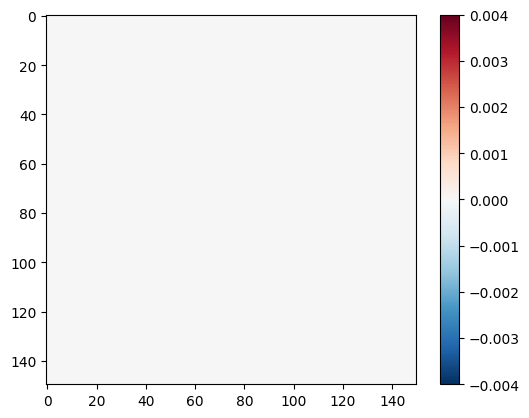

In [16]:
da = 6 # сохраняем каждый n-ый кадр для анимации
data = Ez_time[::da] # сечение Ez в середине моделирования
fig, ax = plt.subplots()
norm = Normalize(vmin=-4e-3, vmax=4e-3)
im = ax.imshow(data[0], cmap='RdBu_r', norm=norm, interpolation="nearest", animated=True)
fig.colorbar(im, ax=ax)

def update(frame):
    im.set_array(data[frame]) # отображаем каждый второй пиксель для ускорения анимации
    return im

ani = animation.FuncAnimation(fig, update, frames=len(data), blit=False)

ani.save("heatmap03.mp4", writer="ffmpeg", fps=20, dpi=100, codec="libx264", extra_args=["-preset", "ultrafast", "-pix_fmt", "yuv420p",
        "-profile:v", "high",
        "-level", "4.0"])